In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import h5py as h5
import sys
import glob
import seaborn as sns

#if necessary adjust the path from where to load stuff, but they should mostly live in the same dir:
sys.path.append("lib")
sys.path.append("../make_plots/")

import plot_utils

from POCAMSiPMHandler import breakdown_func, baseline, ampl

from pcm_monitoring_func import decode_value, get_timestamps, getADCreadings, extract_per_pwm, convert_to_perTrig, get_SiPM_dt



In [2]:
sns.set_palette('colorblind')

In [3]:
hem = '03'
pocam = '002'

batch = 'batch2'

T= -20

f_ = h5.File(f"/home/ecp/disk1/pocam_data/{batch}/prod_characterization_{hem}/Self_Monitoring_data_{T}C.h5")

In [4]:
all_data = {}
for sipm_pwm_ in f_['metadata/sipm_pwm']:
    all_data[sipm_pwm_]= {}
    for flm_ in f_['metadata']['flasher_modes']:
        all_data[sipm_pwm_][flm_.decode()] = extract_per_pwm(f_['flashes/{:d}/{:s}'.format(sipm_pwm_, flm_.decode())])

In [5]:
data_dict = {}


for flasher in ['lmg0', 'lmg1', 'lmg2', 'lmg3', 'kapu0', 'kapu3']:
    data_dict[flasher] = {}
    data_dict[flasher]["sipm_data"] = {}
    data_dict[flasher]["pd_data"] = {}
    
    lmg1_app = '_A'
        
    # fig = plt.figure(figsize=(10,7), facecolor="w")
    # ax = fig.add_axes([0.08,0.08,0.88,0.88])
    
    for sipm_pwm_ in f_['metadata']['sipm_pwm'][()]:#[:2]: 
        # data_dict[flasher]["sipm_data"][str(sipm_pwm_)] = {}
        if not 'lmg1' in flasher:
            flasher_pd = flasher
        elif 'lmg1' in flasher:
            flasher_pd = flasher + lmg1_app#flasher_pd
        
        
        plotval = np.array([all_data[sipm_pwm_][flasher_pd][fpwm_]['adcA']['sum'].mean() for fpwm_ in f_['metadata']['flasher_pwm'][()] ] )
        #print(plotval)
        #print(flasher)
        try:
            pass
            #plotval = plotval - all_data[sipm_pwm_][flasher_pd][0]['adcA']['peak'].mean()
            #print(all_data[sipm_pwm_][flasher_pd][0]['adcA']['peak'].mean(),'\n\n')
            #plotval = plotval/np.max(plotval)
        except:
            print('no flasher pwm 0')
        """
        ax.plot(
            f_['metadata']['flasher_pwm'][()],
            plotval/10**5,
            color="purple",
        )
        plt.scatter(
            f_['metadata']['flasher_pwm'][()],
            plotval/10**5,
            color="purple",
            label='adcA vs flasher-pwm'
        )
        
        """
        data_dict[flasher]["pd_data"]['adcA'] = {}
        data_dict[flasher]["pd_data"]['adcA']['flasher_pwm'] = f_['metadata']['flasher_pwm'][()]
        data_dict[flasher]["pd_data"]['adcA']['adcA_peak_mean'] = plotval
        data_dict[flasher]["pd_data"]['adcA']['adcA_peak_std'] = np.array([all_data[sipm_pwm_][flasher_pd][fpwm_]['adcA']['peak'].std() for fpwm_ in f_['metadata']['flasher_pwm'][()] ] )

        plotval = np.array([all_data[sipm_pwm_][flasher_pd][fpwm_]['adcB']['sum'].mean() for fpwm_ in f_['metadata']['flasher_pwm'][()] ] )
        try:
            pass
            #plotval = plotval - all_data[sipm_pwm_][flasher_pd][0]['adcB']['peak'].mean()
            #plotval = plotval/np.max(plotval)
        except:
            print('no flasher pwm 0')
        
        # ax.plot(
        #     f_['metadata']['flasher_pwm'][()],
        #     plotval/10**5,
        #     color="blue",
        # )
        
        # ax.scatter(
        #     f_['metadata']['flasher_pwm'][()],
        #     plotval/10**5,
        #     color="blue",
        #     label='adcB vs flasher-pwm'
        # )
        
        #print(plotval)
        
        data_dict[flasher]["pd_data"]['adcB'] = {}
        data_dict[flasher]["pd_data"]['adcB']['flasher_pwm'] = f_['metadata']['flasher_pwm'][()]
        data_dict[flasher]["pd_data"]['adcB']['adcB_peak_mean'] = plotval
        data_dict[flasher]["pd_data"]['adcB']['adcB_peak_std'] = np.array([all_data[sipm_pwm_][flasher_pd][fpwm_]['adcB']['peak'].std() for fpwm_ in f_['metadata']['flasher_pwm'][()] ] )

        # ax.set_title(flasher.upper(), fontsize=16)

        # ax.set_xlabel("Emitter PWM [a.u.]", fontsize=18)

        # ax.set_ylabel("Self-Monitoring Signals [a.u.]", fontsize=18)

        # ax.grid('both')
        plotval = np.array([all_data[sipm_pwm_][flasher_pd][fpwm_]['tdc2_dt'].mean() for fpwm_ in f_['metadata']['flasher_pwm'][()] ] )
        data_dict[flasher]["sipm_data"]['tdc2'] = {}
        data_dict[flasher]["sipm_data"]['tdc2']['flasher_pwm'] = f_['metadata']['flasher_pwm'][()]
        data_dict[flasher]["sipm_data"]['tdc2']['tdc2_peak_mean'] = plotval
        data_dict[flasher]["sipm_data"]['tdc2']['tdc2_peak_std'] = np.array([all_data[sipm_pwm_][flasher_pd][fpwm_]['tdc2_dt'].std() for fpwm_ in f_['metadata']['flasher_pwm'][()] ] )


        # ax.legend(loc='best')    
    

In [6]:
filepath = f'../output/batch2/pocam_{pocam}/hem_{hem}/LMG405/photons_*_-40C_1-20.json'

filelist = glob.glob(filepath)


In [7]:
filelist

['../output/batch2/pocam_002/hem_03/LMG405/photons_54000_-40C_1-20.json',
 '../output/batch2/pocam_002/hem_03/LMG405/photons_10000_-40C_1-20.json',
 '../output/batch2/pocam_002/hem_03/LMG405/photons_20000_-40C_1-20.json',
 '../output/batch2/pocam_002/hem_03/LMG405/photons_25000_-40C_1-20.json',
 '../output/batch2/pocam_002/hem_03/LMG405/photons_7500_-40C_1-20.json',
 '../output/batch2/pocam_002/hem_03/LMG405/photons_35000_-40C_1-20.json',
 '../output/batch2/pocam_002/hem_03/LMG405/photons_15000_-40C_1-20.json']

In [8]:
import json

In [9]:
pwm = []
val_pd = []
val_pmt = []
for file in filelist:
    with open(file, 'r') as f:
        data = json.load(f)
        pwm.append(data['meas_data'][0]['power'])
        val_pd.append(data['meas_data'][0]['value'])
        # val_pmt.append(data['meas_data'][1]['value'])

sorted_idx = np.argsort(pwm)
pwm  = np.array(pwm)[sorted_idx]
val_pd = np.array(val_pd)[sorted_idx]
# val_pmt = np.array(val_pmt)[sorted_idx]

In [10]:
data_dict['kapu0']['pd_data']['adcA']['flasher_pwm']

array([   -1,     0,  7500, 10000, 12500, 15000, 17500, 20000, 25000,
       30000, 35000, 45000, 54000])

In [11]:
emitters = [('lmg0','LMG405'), ('lmg1','LMG365'), ('lmg2','LMG520'), ('lmg3','LMG450'), ('kapu0','KAPU405'), ('kapu3','KAPU465')]

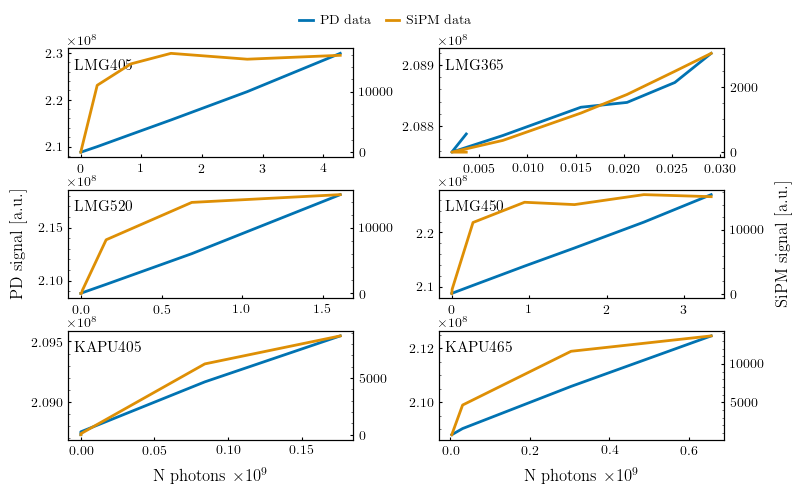

In [13]:
fig, axes = plt.subplots(3, 2, figsize=plot_utils.set_size('wide', fraction=1.2, ratio=0.4, subplots=(3, 2)))

for i, ax in enumerate(axes.flat):
    emitter = emitters[i]
    dev_sm = emitter[0]
    dev_name = emitter[1]
    
    if 'LMG' in  dev_name:
        filepath = f'../output/batch2/pocam_{pocam}/hem_{hem}/{dev_name}/photons_*_{T}C_1-20.json'
    if 'KAPU' in dev_name:
        filepath = f'../output/batch2/pocam_{pocam}/hem_{hem}/{dev_name}/photons_*_{T}C_default.json'

    filelist = glob.glob(filepath)

    pwm = []
    val_pd = []
    val_pmt = []
    for file in filelist:
        with open(file, 'r') as f:
            data = json.load(f)
            pwm.append(data['meas_data'][0]['power'])
            val_pd.append(data['meas_data'][0]['value'])
            # val_pmt.append(data['meas_data'][1]['value'])

    sorted_idx = np.argsort(pwm)
    pwm  = np.array(pwm)[sorted_idx]
    val_pd = np.array(val_pd)[sorted_idx]
    # val_pmt = np.array(val_pmt)[sorted_idx]
    #pd data
    mask = np.isin(data_dict[dev_sm]['pd_data']['adcA']['flasher_pwm'], pwm)
    ax.plot(val_pd/10**9, data_dict[dev_sm]['pd_data']['adcA']['adcA_peak_mean'][mask], color = 'C0' )
    ax.text(0.02,0.8, dev_name, transform=ax.transAxes, size = 11)
    if i == 4 or i == 5:
        ax.set_xlabel(r"N photons $\times 10^9$")
    if i ==2:
        ax.set_ylabel("PD signal [a.u.]")

    #sipm data
    mask = np.isin(data_dict[dev_sm]['sipm_data']['tdc2']['flasher_pwm'], pwm)
    ax1 = ax.twinx()
    ax1.plot(val_pd/10**9, data_dict[dev_sm]['sipm_data']['tdc2']['tdc2_peak_mean'][mask], color = 'C1')
    if i ==3:
        ax1.set_ylabel("SiPM signal [a.u.]")

plt.subplots_adjust(hspace=0.3, wspace=0.3)

# legend with manual handles, centered on top
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], color='C0', label='PD data'),
    Line2D([0], [0], color='C1', label='SiPM data'),
]
fig.legend(handles=handles, loc='upper center', ncol=2,
           bbox_to_anchor=(0.5, 0.97), frameon=False, columnspacing=1)

plt.savefig(f'../make_plots/plots/png/self_monitoring_hem{hem}_T{T}C.png', dpi=300, bbox_inches='tight')
plt.savefig(f'../make_plots/plots/pdf/self_monitoring_hem{hem}_T{T}C.pdf', dpi=300, bbox_inches='tight')
